# Phase 7 — Paper Figures (Revision Round 2)

Generates all updated figures for the revision:
- **Figs 12–13**: Stress test split into two separate figures
  - `stress_amplitude_fig.png` — amplitude scaling, all 7 methods
  - `stress_duty_cycle_fig.png` — duty cycle masking, all 7 methods
- **Figs 6–7 (standalone)**: Cyclo invocation bar chart and burst length histogram
  loaded from `cascade_stats.json` / `burst_lengths.npy` (no need to re-run main notebook).
  These are identical to the in-place updates in `cascade-signal-detection-drone-rf.ipynb`.

**Prerequisites:**
- `results/review_1/cnn_stress_amplitude.csv` — from `phase4_cnn_baseline.ipynb`
- `results/review_1/cnn_stress_duty_cycle.csv` — from `phase4_cnn_baseline.ipynb`
- `results/review_1/cascade_stats.json` — from `cascade-signal-detection-drone-rf.ipynb`
- `results/review_1/burst_lengths.npy` — from `cascade-signal-detection-drone-rf.ipynb`

No (a)/(b) subplot labels — these will be added manually in Word per MDPI template.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path().resolve().parents[2]
OUT  = ROOT / "results" / "review_1"

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
})

METHOD_COLORS = {
    "Energy":     "#1f77b4",
    "Wavelet":    "#ff7f0e",
    "Cyclo":      "#2ca02c",
    "Cascade":    "#d62728",
    "AED-global": "#9467bd",
    "AED-perseg": "#8c564b",
    "CNN":        "#e377c2",
}
METHOD_MARKERS = {
    "Energy": "o", "Wavelet": "s", "Cyclo": "^", "Cascade": "D",
    "AED-global": "P", "AED-perseg": "X", "CNN": "v",
}

def pd_cols(df):
    """Return (method_name, Pd_col) pairs for all *_Pd columns in df."""
    return [(col[:-3], col) for col in df.columns if col.endswith("_Pd")]

print(f"OUT: {OUT}")

OUT: /home/ivan/work/ml/rfml-uav/results/review_1


---
## Figure 12 — Amplitude stress (all 7 methods)

Loads `cnn_stress_amplitude.csv` which contains Pd columns for all 7 methods
across 5 amplitude scaling values (α ∈ {1.0, 0.5, 0.25, 0.10, 0.05}).

Columns: ['alpha', 'Energy_Pd', 'Energy_AUC', 'Wavelet_Pd', 'Wavelet_AUC', 'Cyclo_Pd', 'Cyclo_AUC', 'Cascade_Pd', 'Cascade_AUC', 'AED-global_Pd', 'AED-global_AUC', 'AED-perseg_Pd', 'AED-perseg_AUC', 'db_reduction', 'CNN_Pd', 'CNN_AUC']
 alpha  db_reduction  Energy_Pd  Wavelet_Pd  Cyclo_Pd  Cascade_Pd  AED-global_Pd  AED-perseg_Pd  CNN_Pd
  1.00        0.0000   1.000000    1.000000  1.000000    1.000000       1.000000       0.580645     1.0
  0.50       -6.0206   1.000000    1.000000  1.000000    1.000000       1.000000       0.580645     1.0
  0.25      -12.0412   1.000000    1.000000  1.000000    1.000000       1.000000       0.580645     1.0
  0.10      -20.0000   0.994624    0.994624  0.994624    1.000000       0.994624       0.580645     1.0
  0.05      -26.0206   0.940860    0.940860  0.951613    0.994624       0.940860       0.580645     1.0


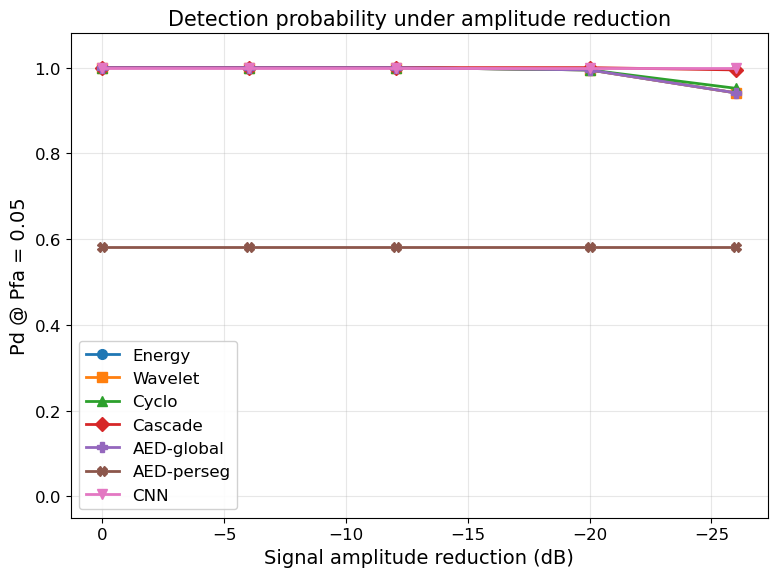

Saved: stress_amplitude_fig.png


In [2]:
df_amp = pd.read_csv(OUT / "cnn_stress_amplitude.csv")
print(f"Columns: {df_amp.columns.tolist()}")
print(df_amp[["alpha", "db_reduction"] + [c for c in df_amp.columns if c.endswith("_Pd")]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))

db_vals = df_amp["db_reduction"].values
for method, col in pd_cols(df_amp):
    color  = METHOD_COLORS.get(method, "gray")
    marker = METHOD_MARKERS.get(method, "o")
    ax.plot(db_vals, df_amp[col].values,
            color=color, marker=marker, linewidth=2, markersize=7,
            label=method)

ax.set_xlabel("Signal amplitude reduction (dB)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("Detection probability under amplitude reduction")
ax.set_ylim(-0.05, 1.08)
ax.invert_xaxis()
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "stress_amplitude_fig.png", dpi=200)
plt.show()
print("Saved: stress_amplitude_fig.png")

---
## Figure 13 — Duty cycle stress (all 7 methods)

Loads `cnn_stress_duty_cycle.csv` which contains Pd columns for all 7 methods
across 4 duty cycle values (dc ∈ {100%, 50%, 25%, 10%}).

Columns: ['duty_cycle', 'Energy_Pd', 'Energy_AUC', 'Wavelet_Pd', 'Wavelet_AUC', 'Cyclo_Pd', 'Cyclo_AUC', 'Cascade_Pd', 'Cascade_AUC', 'AED-global_Pd', 'AED-global_AUC', 'AED-perseg_Pd', 'AED-perseg_AUC', 'duty_cycle_pct', 'CNN_Pd', 'CNN_AUC']


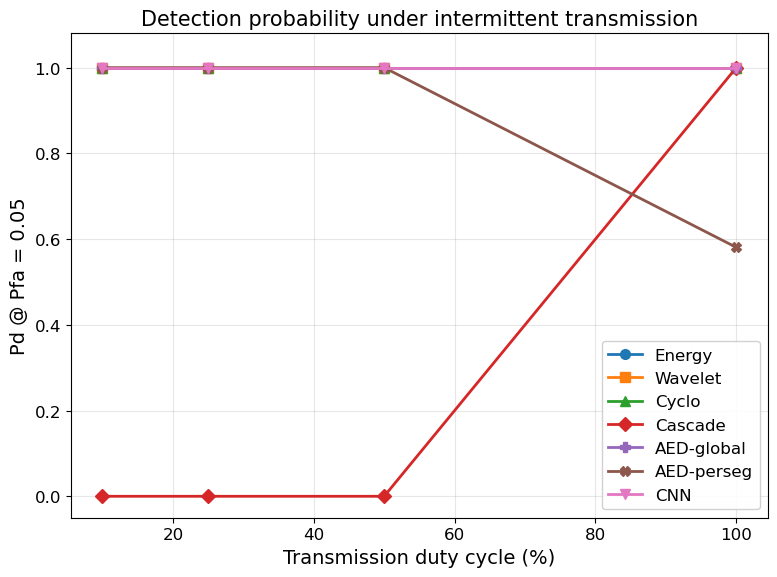

Saved: stress_duty_cycle_fig.png


In [3]:
df_dc = pd.read_csv(OUT / "cnn_stress_duty_cycle.csv")
print(f"Columns: {df_dc.columns.tolist()}")

# Use duty_cycle_pct column if present, else compute from duty_cycle
if "duty_cycle_pct" in df_dc.columns:
    dc_pct = df_dc["duty_cycle_pct"].values
else:
    dc_pct = df_dc["duty_cycle"].values * 100

fig, ax = plt.subplots(figsize=(8, 6))

for method, col in pd_cols(df_dc):
    color  = METHOD_COLORS.get(method, "gray")
    marker = METHOD_MARKERS.get(method, "o")
    ax.plot(dc_pct, df_dc[col].values,
            color=color, marker=marker, linewidth=2, markersize=7,
            label=method)

ax.set_xlabel("Transmission duty cycle (%)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("Detection probability under intermittent transmission")
ax.set_ylim(-0.05, 1.08)
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "stress_duty_cycle_fig.png", dpi=200)
plt.show()
print("Saved: stress_duty_cycle_fig.png")

---
## Figures 6–7 (standalone)

Regenerates the cyclo invocation bar chart and burst length histogram from saved
JSON/npy files. Useful if the main notebook kernel is cold.

**Requires:** run `cascade-signal-detection-drone-rf.ipynb` at least once to generate
`cascade_stats.json` and `burst_lengths.npy`.

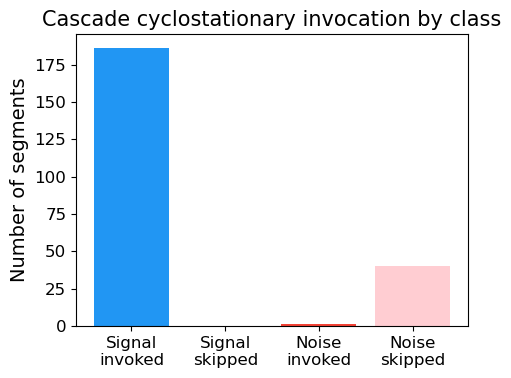

Saved: main_cyclo_invocation.png


In [4]:
with open(OUT / "cascade_stats.json") as f:
    stats = json.load(f)

n_sig = stats["segments_signal"]
n_noi = stats["segments_noise"]

fig, ax = plt.subplots(figsize=(5, 4))
labels_bar = ["Signal\ninvoked", "Signal\nskipped", "Noise\ninvoked", "Noise\nskipped"]
values_bar = [
    stats["segments_cyclo_signal"],
    n_sig - stats["segments_cyclo_signal"],
    stats["segments_cyclo_noise"],
    n_noi - stats["segments_cyclo_noise"],
]
colors = ["#2196F3", "#90CAF9", "#F44336", "#FFCDD2"]
ax.bar(labels_bar, values_bar, color=colors)
ax.set_ylabel("Number of segments")
ax.set_title("Cascade cyclostationary invocation by class")
fig.tight_layout()
fig.savefig(OUT / "main_cyclo_invocation.png", dpi=200)
plt.show()
print("Saved: main_cyclo_invocation.png")

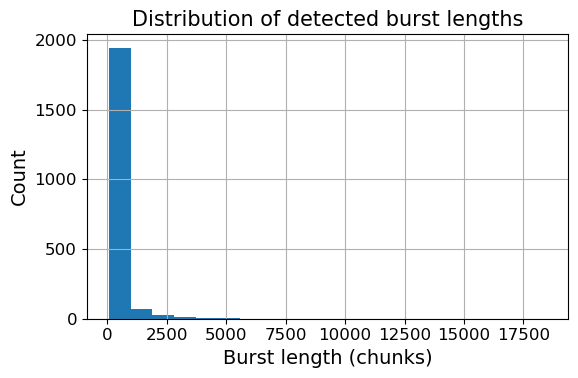

Saved: main_burst_dist.png


In [5]:
burst_lengths = np.load(OUT / "burst_lengths.npy")

plt.figure(figsize=(6, 4))
plt.hist(burst_lengths, bins=20)
plt.xlabel("Burst length (chunks)")
plt.ylabel("Count")
plt.title("Distribution of detected burst lengths")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT / "main_burst_dist.png", dpi=200)
plt.show()
print("Saved: main_burst_dist.png")